In [1]:
import os
import datetime as dt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import polars as pl
import seaborn as sns

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.stats import jarque_bera, kurtosis
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

plt.style.use('default')

In [2]:
def filter_and_format_data(data, exchange):
    # Filter for ETH-USDT trades on OKX exchange
    data_exch = data.filter(pl.col('Exchange') == exchange)

    # Convert ts to datetime using polars
    data_exch = data_exch.with_columns(
        pl.col('ts').cast(pl.Datetime)
    )

    # sort by timestamp
    data_exch = data_exch.sort('ts')

    data_exch = data_exch.with_columns(
        (pl.col('qty') * (pl.col('side') == 'B')).alias('buy_qty'),
        (pl.col('qty') * (pl.col('side') == 'A')).alias('sell_qty')
    )

    # resample data to 1 sec intervals
    data_exch = data_exch.group_by_dynamic("ts", every="1s").agg([
        pl.col('trade_price').last(),
        pl.col('buy_qty').sum(),
        pl.col('sell_qty').sum()
    ])

    data_exch = data_exch.upsample(time_column="ts", every="1s")
    data_exch = data_exch.with_columns(
        pl.col('trade_price').fill_null(strategy='forward'),
        pl.col('buy_qty').fill_null(0),
        pl.col('sell_qty').fill_null(0)
    )

    data_exch = data_exch.with_columns(
        pl.col('trade_price').pct_change().alias('return')
    )

    return data_exch

In [3]:
def display_price_volume_and_return_bounds(data, cutoff_time, exchange):
    cutoff_time = data['ts'].min() + pd.Timedelta(cutoff_time)
    temp = data.filter(pl.col('ts') < cutoff_time)

    # calculate rolling 5-second volatility of returns
    temp = temp.with_columns(
        temp.rolling(index_column="ts", period=f'5s').agg([
            pl.col('return').std().alias('vol'),
        ]).select(pl.col('vol'))
    )

    # calculate upper and lower bounds as +/- 2 * vol shifted by 1 time point
    temp = temp.with_columns(
        (2 * pl.col('vol').shift(1)).alias('upper_bound'),
        (-2 * pl.col('vol').shift(1)).alias('lower_bound')
    )

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

    ax1.plot(temp['ts'], temp['trade_price'])

    ax1.set_title(f'ETH-USDT Trade Prices on {exchange} Exchange')
    ax1.set_xlabel('Time')
    ax1.set_ylabel('Trade Price (USDT)')
    # ax1.grid()

    ax1t = ax1.twinx()
    ax1t.bar(temp['ts'], temp['buy_qty'], width=dt.timedelta(seconds=1), color='green', alpha=0.6, label='Buy Qty (1s)')
    ax1t.bar(temp['ts'], -temp['sell_qty'], width=dt.timedelta(seconds=1), color='red', alpha=0.6, label='Sell Qty (1s)')
    ax1t.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    ax1t.set_ylim(max(-100, (-1 * temp['sell_qty'].max()) - 2), min(100, temp['buy_qty'].max() + 2))
    ax1t.set_ylabel('Buy/Sell Quantity (1s)')
    ax1t.legend(loc='upper left')

    ax2.plot(temp['ts'], temp.select(pl.col('return')), color='blue', label='Return')
    ax2.plot(temp['ts'], temp.select(pl.col('upper_bound')), color='green', label='+2 std')
    ax2.plot(temp['ts'], temp.select(pl.col('lower_bound')), color='red', label='-2 std')
    ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    ax2.set_title(f'Returns and 5-Second Rolling Volatility based on t-1 time point')
    ax2.set_xlabel('Time')
    ax2.set_ylabel('Log Return')
    ax2.legend()
    ax2.grid()

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    return temp

In [4]:
def tests(data):
    # plot autocorrelation and partial autocorrelation of returns
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 5))
    plot_acf(data['return'].drop_nulls(), lags=50, ax=ax1)
    ax1.set_title('Autocorrelation of Returns (1s)')

    plot_pacf(data['return'].drop_nulls(), lags=50, ax=ax2)
    ax2.set_title('Partial Autocorrelation of Returns (1s)')
    plt.tight_layout()
    plt.show()

    # Calculate skewness and kurtosis and make inferences about the distribution
    skewness = data['return'].skew()
    kurtosis = data['return'].kurtosis()

    if skewness > 0:
        print('Distribtion is positively skewed')
    else:
        print('Distribtion is negatively skewed')

    if kurtosis > 3:
        print('Kurtosis > 3 implies Distribtion has heavy tails')
    else:
        print('Kurtosis <= 3 implies Distribtion has thinner tails')
    
    # Calculate Jarque-Bera test for normality of returns
    jb_stat, jb_pvalue = jarque_bera(data['return'].drop_nulls().to_numpy())
    print(f'Jarque-Bera test statistic: {jb_stat}, p-value: {jb_pvalue}')
    print('This indicates that the returns are not normally distributed.' if jb_pvalue < 0.05 else 'This indicates that the returns are normally distributed.')

    # Calculate ADF test for stationarity of returns
    adf_stat, adf_pvalue, _, _, _, _ = adfuller(data['return'].drop_nulls().to_numpy())
    print(f'\nADF test statistic: {adf_stat}, p-value: {adf_pvalue}')
    print('This indicates that the returns are stationary.' if adf_pvalue < 0.05 else 'This indicates that the returns are non-stationary.')

In [5]:
def generate_data_for_regression(data, t, Ts):
    data = data.sort('ts')

    feature_columns = []

    # For each timestamp, get the previous t sec look-back data to have t returns, volatility, buy volume, sell volume
    for lag in range(1, t+1):
        # rolling window aggregations polars
        temp = data.rolling(index_column="ts", period=f'{lag}s').agg([
            ((1 + pl.col("return")).product() - 1).alias(f'return_lag_{lag}'),
            pl.col("return").std().alias(f'vol_lag_{lag}'),
            # pl.col("buy_qty").sum().alias(f'buy_qty_lag_{lag}'),
            # pl.col("sell_qty").sum().alias(f'sell_qty_lag_{lag}')
        ])

        data = data.with_columns(
            temp.fill_null(0)
        )

        feature_columns.extend([f'return_lag_{lag}', f'vol_lag_{lag}'])#, f'buy_qty_lag_{lag}', f'sell_qty_lag_{lag}'])

    y_labels = []
    for T in Ts:
        forward = data.rolling(index_column="ts", period=f'{T}s', offset="0d").agg([
            pl.col("trade_price").last().alias("last")
        ])
        data = data.with_columns(
            ((forward['last'] / pl.col('trade_price')) - 1).alias(f'return_forward_{T}')
        )

        y_label = f'return_forward_{T}'
        y_labels.append(y_label)

    feature_columns.remove('vol_lag_1')  # remove vol_lag_1 which is always 0

    all_columns = ['ts','trade_price'] + y_labels + feature_columns
    data = data.select(pl.col(all_columns))

    return data, y_labels, feature_columns

In [6]:
def fast_vif_drop(df, threshold=10.0):
    """
    Recursively drops features with the highest VIF using matrix inversion.
    """
    cols = list(df.columns)
    while True:
        # Calculate the correlation matrix
        corr = df[cols].corr().values

        # Calculate the inverse of the correlation matrix
        # If the matrix is singular (perfect collinearity), this will fail.
        # We add a tiny bit of noise to the diagonal for stability.
        try:
            inv_corr = np.linalg.inv(corr)
        except np.linalg.LinAlgError:
            # Handle perfect collinearity by dropping one of the offenders manually
            # or using pseudo-inverse
            inv_corr = np.linalg.pinv(corr)

        # VIFs are the diagonal elements
        vifs = np.diagonal(inv_corr)
        max_vif_idx = np.argmax(vifs)
        max_vif = vifs[max_vif_idx]

        if max_vif > threshold:
            print(f"Dropping '{cols[max_vif_idx]}' (Fast VIF: {max_vif:.2f})")
            cols.pop(max_vif_idx)
        else:
            break

    return df[cols], cols, vifs

In [7]:
def perform_training_regression_analysis(data, y_label, feature_columns):
    X = data.select(pl.col(feature_columns)).to_pandas()
    y = data.select([y_label]).to_pandas()


    print('\nStarting Variance Inflation Factor (VIF) Analysis')
    X, feature_columns, vifs = fast_vif_drop(X, 5)

    vif_data_fast = pd.DataFrame({'feature': feature_columns, 'VIF': vifs})

    vif_data = pd.DataFrame()
    vif_data["feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

    # Recursive remove highest VIF feature until all VIF < 10
    while np.any(vif_data["VIF"] > 5):
        max_vif_feature = vif_data.loc[vif_data["VIF"].idxmax(), "feature"]
        print(f'Removing feature {max_vif_feature} with VIF {vif_data["VIF"].max():.2f}')
        feature_columns.remove(max_vif_feature)
        X = reg_train.select(pl.col(feature_columns)).to_pandas()
        vif_data = pd.DataFrame()
        vif_data["feature"] = X.columns
        vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

    print()

    vif_data.sort_values(by="VIF", ascending=False, inplace=True)

    model = sm.OLS(y, X).fit()

    print(model.summary())

    model.params.sort_values().plot(kind='barh', figsize=(8,4))
    plt.show()

    # Add beta coefficients to vif_data
    vif_data["beta_coefficient"] = vif_data["feature"].map(lambda x: model.params[x])

    # format VIF values and beta
    display(vif_data.style.format({"VIF": "{:.2f}", "beta_coefficient": "{:.4f}"}))

    return model, feature_columns

In [8]:
def perform_test_analysis(model, data, y_label, feature_columns):
    # Plot Cumulative returns predicted vs actual for test set
    data_test = data.group_by_dynamic("ts", every="5s").agg([
        pl.col(col).last() for col in [y_label] + feature_columns
    ])

    X_test = data_test.select(pl.col(feature_columns)).to_pandas()
    # y_test = data_test.select([y_label]).to_pandas()
    y_pred = model.predict(X_test)
    data_test_pd = data_test.to_pandas()
    data_test_pd['predicted_return'] = y_pred
    data_test_pd['actual_cumprod'] = (1 + data_test_pd[y_label]).cumprod()
    data_test_pd['predicted_cumprod'] = (1 + data_test_pd['predicted_return']).cumprod()

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15,10))

    ax1.plot(data_test_pd['ts'], data_test_pd['actual_cumprod'], label='Actual Cumulative Return')
    ax1.plot(data_test_pd['ts'], data_test_pd['predicted_cumprod'], label='Predicted Cumulative Return')
    ax1.set_title('Actual vs Predicted Cumulative Return on Test Set')
    ax1.set_xlabel('Time')
    ax1.set_ylabel('Cumulative Return')
    ax1.legend()
    ax1.grid()

    # plot actual vs predicted returns scatter plot
    ax2.scatter(data_test_pd[y_label], data_test_pd['predicted_return'], alpha=0.5)
    ax2.set_title('Actual vs Predicted Returns on Test Set')
    ax2.set_xlabel('Actual Return')
    ax2.set_ylabel('Predicted Return')
    ax2.grid()

    plt.show()

    # Calculate win rate on test set
    data_test_pd['correct_sign'] = np.sign(data_test_pd[y_label]) == np.sign(data_test_pd['predicted_return'])
    win_rate = data_test_pd['correct_sign'].mean()
    print('*'*30, f'Win Rate on Test Set: {win_rate:.4f}', '*'*30)

In [9]:
def calculate_performance_metrics(capital_series, periods_per_year=252):

    total_pnl = capital_series.iloc[-1] - capital_series.iloc[0]
    total_return = (capital_series.iloc[-1] / capital_series.iloc[0]) - 1

    # Max Drawdown
    running_max = capital_series.cummax()
    drawdown = (capital_series - running_max) / running_max
    max_drawdown = drawdown.min()

    # Annualized Sharpe
    returns = capital_series.pct_change().dropna()
    if returns.std() == 0:
        sharpe_ratio = 0
    else:
        sharpe_ratio = (returns.mean() / returns.std()) * np.sqrt(periods_per_year)
    
    return {
        "Total Return": total_return,
        "Max Drawdown": max_drawdown,
        "Total PnL": total_pnl,
        "Annualized Sharpe": sharpe_ratio
    }

In [10]:
def simulate_trading_strategy_and_performance_analysis(model, data, y_label, feature_columns, threshold, initial_capital=1_000_000.00):

    print('*'*20, f'Threshold for {y_label} trading simulation is {threshold:.8f}', '*'*20)

    X = data.select(pl.col(feature_columns)).to_pandas()
    y = data.select([y_label]).to_pandas()
    y_pred = model.predict(X)
    data_pd = data.to_pandas()
    data_pd['predicted_return'] = y_pred

    lead = int(y_label.split('_')[-1])

    metrics_list = []
    # Simulate trading strategy
    for tc in range(0,4):

        threshold_tc = threshold + 0.0001*tc
        data_pd[f'position_{tc}bp'] = 0
        data_pd.loc[data_pd['predicted_return'] > threshold_tc, f'position_{tc}bp'] = 1  # Long
        data_pd.loc[data_pd['predicted_return'] < -threshold_tc, f'position_{tc}bp'] = -1  # Short

        data_pd[f'strategy_pnl_{tc}bp'] = (data_pd[f'position_{tc}bp'] * (data_pd[y_label] - 0.0001*tc) * data_pd['trade_price']).shift(lead).fillna(0)
        data_pd[f'strategy_cumpnl_{tc}bp'] = data_pd[f'strategy_pnl_{tc}bp'].cumsum()
        data_pd[f'strategy_capital_{tc}bp'] = data_pd[f'strategy_cumpnl_{tc}bp'] + initial_capital

        win_rate = (data_pd[f'strategy_pnl_{tc}bp'] > 0).sum() / data_pd[f'position_{tc}bp'].abs().sum()
        
        # Compute Total Return, Max Drawdown, Annualized Sharpe
        metrics = calculate_performance_metrics(data_pd[f'strategy_capital_{tc}bp'], 86400*365)
        metrics['Transaction Cost (bps)'] = tc
        metrics['Win Rate'] = win_rate
        metrics_list.append(metrics)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

    ax1.plot(data_pd['ts'], data_pd['strategy_capital_0bp'], label='Strategy Cumulative Capital')
    ax1.set_title('Trading Strategy Cumulative Capital, No Trading Cost')
    ax1.set_xlabel('Time')
    ax1.set_ylabel('Cumulative Capital')
    ax1.legend()
    ax1.grid()

    for tc in range(1,4):
        ax2.plot(data_pd['ts'], data_pd[f'strategy_capital_{tc}bp'], label=f'Strategy Cumulative Capital, Trading Cost={tc}bp')
    ax2.set_title('Trading Strategy Cumulative Capital, Including Trading Cost')
    ax2.set_xlabel('Time')
    ax2.set_ylabel('Cumulative Capital')
    ax2.legend()
    ax2.grid()

    plt.show()

    # pretty print dictionary with float for pnl and sharpe and % for total return and max drawdown
    metrics_df = pd.DataFrame(metrics_list).set_index('Transaction Cost (bps)')
    print("\nPerformance Metrics:")

    # Pretty print formatted dataframe
    metrics_display = metrics_df.copy()
    metrics_display['Total Return'] = metrics_display['Total Return'].map('{:.2%}'.format)
    metrics_display['Max Drawdown'] = metrics_display['Max Drawdown'].map('{:.2%}'.format)
    metrics_display['Total PnL'] = metrics_display['Total PnL'].map('{:,.2f}'.format)
    metrics_display['Annualized Sharpe'] = metrics_display['Annualized Sharpe'].map('{:.2f}'.format)
    metrics_display['Win Rate'] = metrics_display['Win Rate'].map('{:.2%}'.format)

    print(metrics_display)




                                              OKX
----------------------------------------------------------------------------------------------------


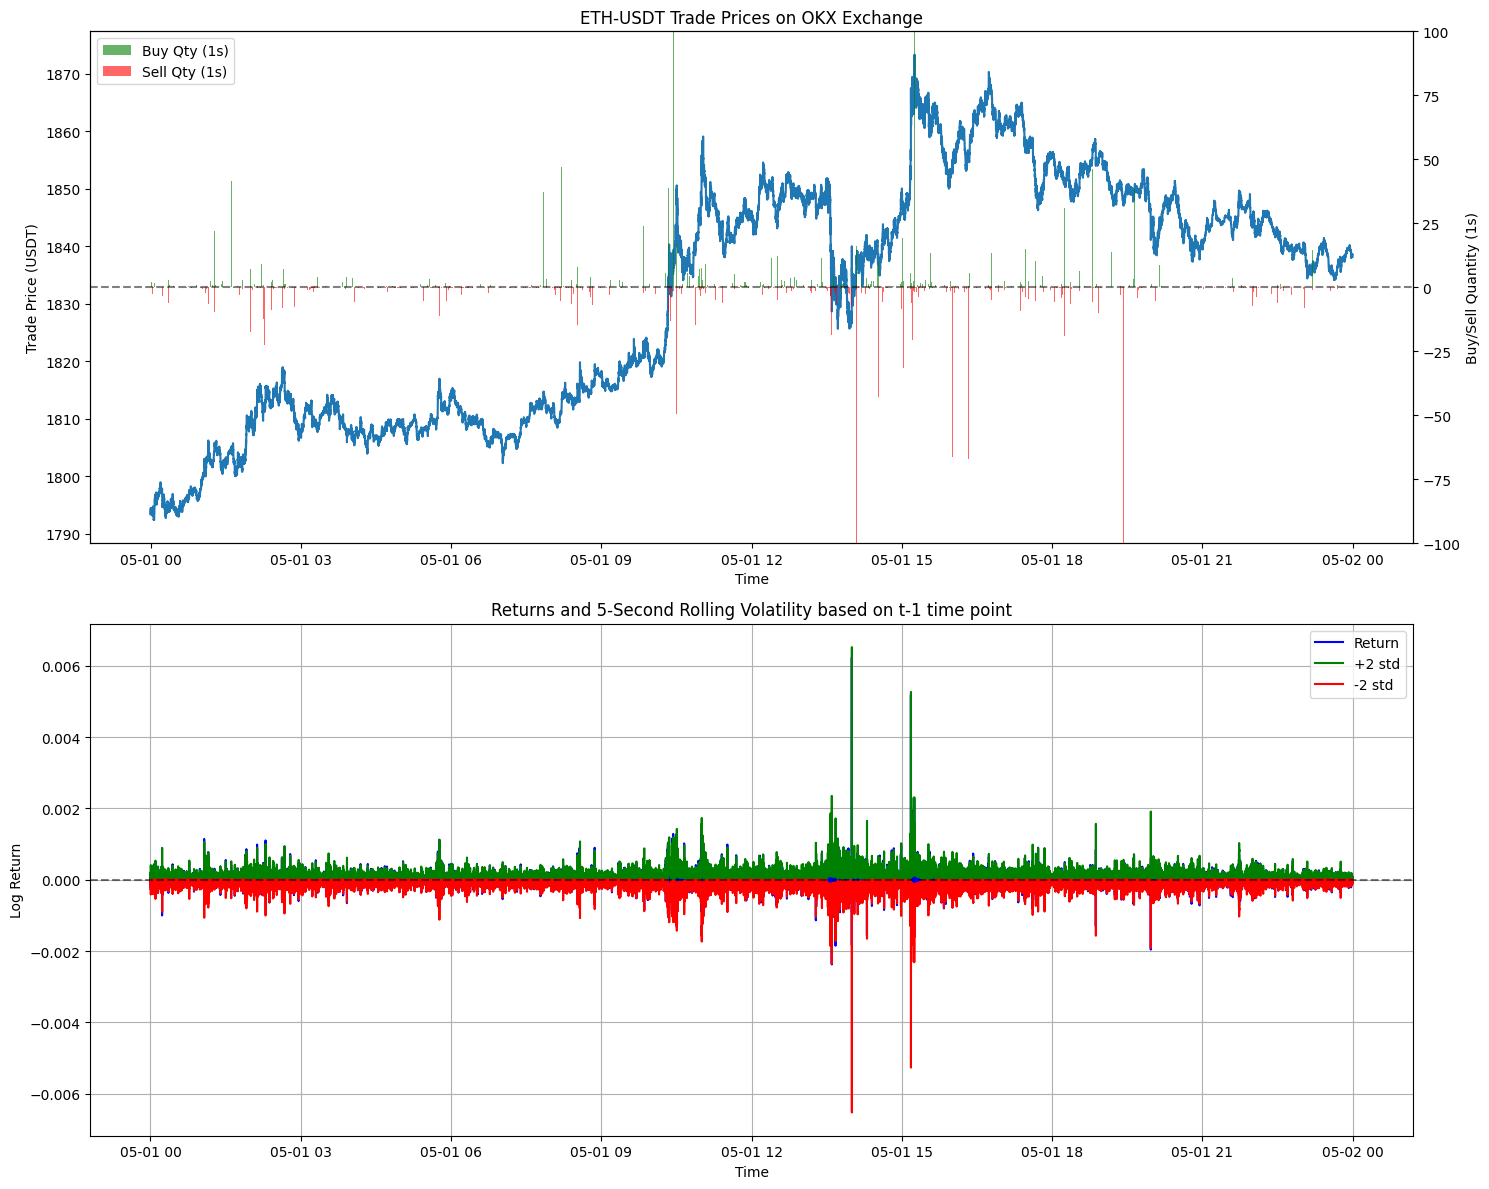

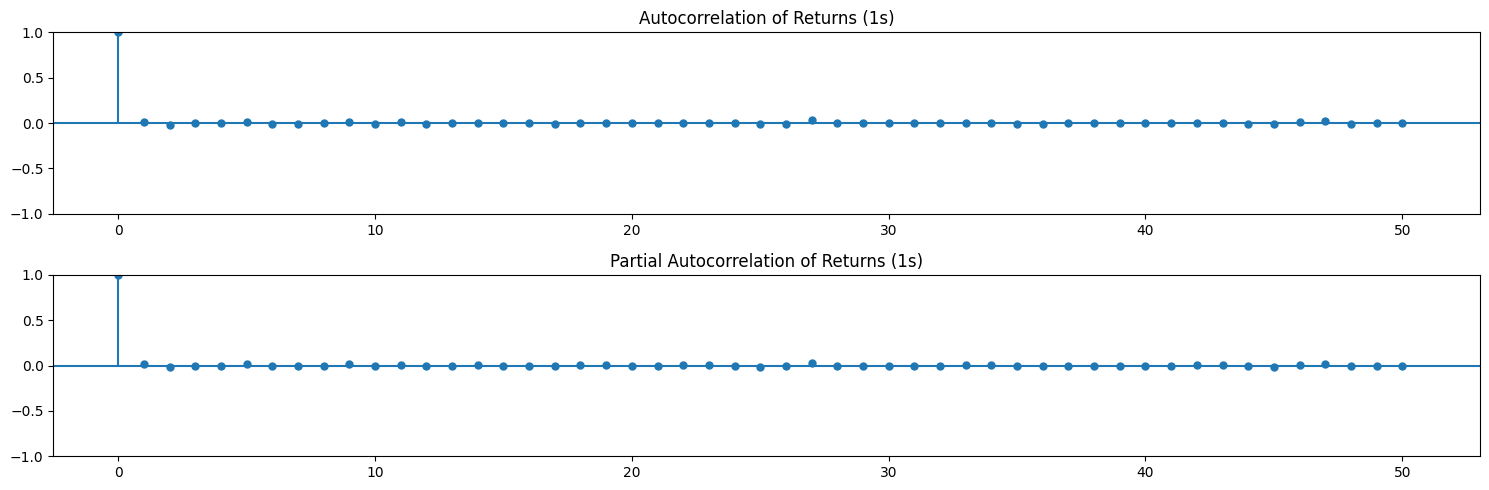

Distribtion is positively skewed
Kurtosis > 3 implies Distribtion has heavy tails
Jarque-Bera test statistic: 438693650.86410826, p-value: 0.0
This indicates that the returns are not normally distributed.

ADF test statistic: -35.80364563163215, p-value: 0.0
This indicates that the returns are stationary.

Starting Variance Inflation Factor (VIF) Analysis
Dropping 'vol_lag_14' (Fast VIF: 126.17)
Dropping 'vol_lag_12' (Fast VIF: 98.13)
Dropping 'vol_lag_10' (Fast VIF: 72.71)
Dropping 'vol_lag_13' (Fast VIF: 52.89)
Dropping 'vol_lag_8' (Fast VIF: 50.55)
Dropping 'vol_lag_6' (Fast VIF: 31.65)
Dropping 'return_lag_14' (Fast VIF: 30.80)
Dropping 'vol_lag_11' (Fast VIF: 29.85)
Dropping 'return_lag_12' (Fast VIF: 26.41)
Dropping 'return_lag_10' (Fast VIF: 22.01)
Dropping 'vol_lag_7' (Fast VIF: 19.43)
Dropping 'return_lag_8' (Fast VIF: 17.55)
Dropping 'vol_lag_4' (Fast VIF: 15.85)
Dropping 'return_lag_13' (Fast VIF: 14.07)
Dropping 'return_lag_6' (Fast VIF: 13.06)
Dropping 'vol_lag_9' (Fast VI

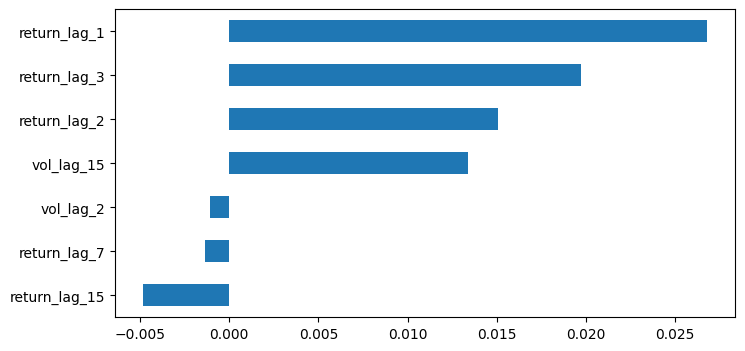

,feature,VIF,beta_coefficient
1,return_lag_2,4.17,0.0151
3,return_lag_3,3.93,0.0197
4,return_lag_7,2.70,-0.0013
2,vol_lag_2,2.20,-0.0011
6,vol_lag_15,2.19,0.0134
0,return_lag_1,2.04,0.0268
5,return_lag_15,1.88,-0.0048


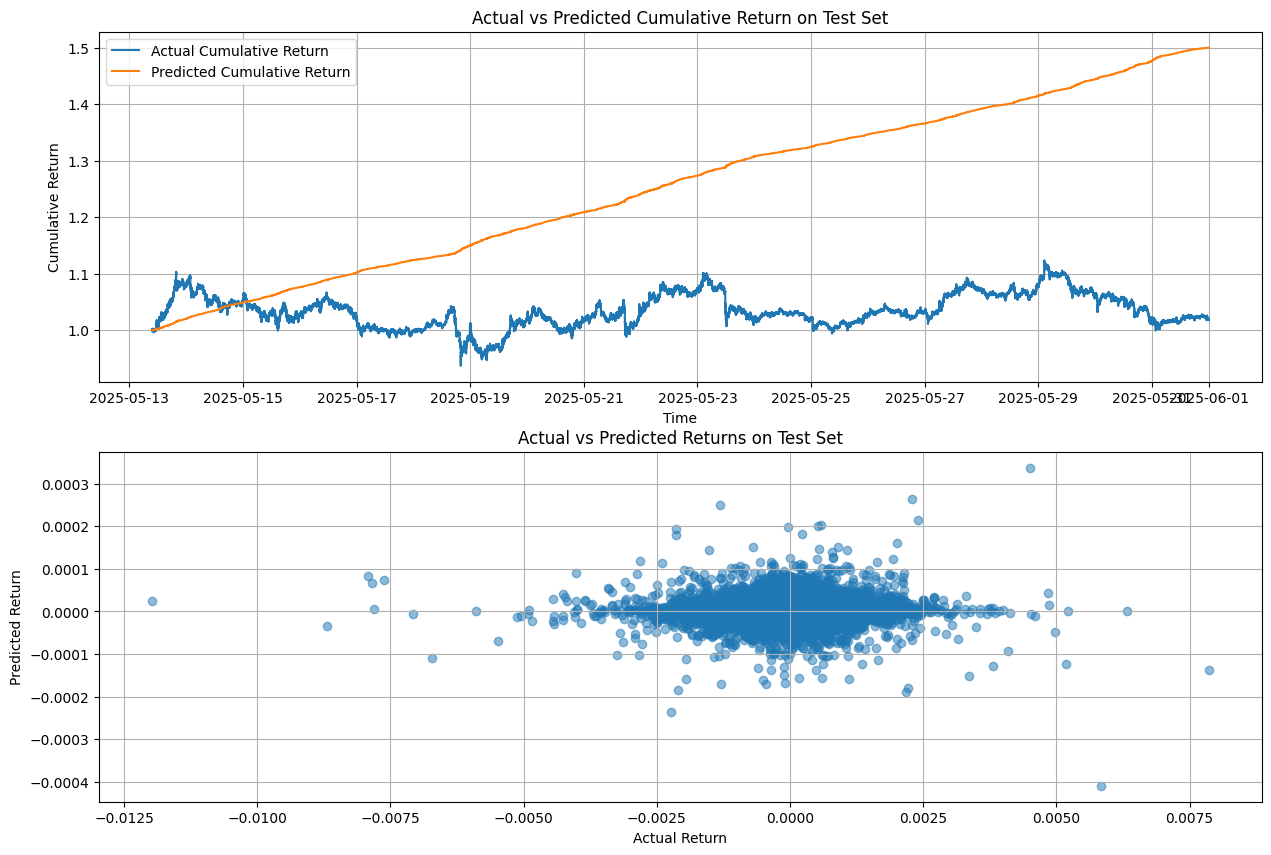

****************************** Win Rate on Test Set: 0.4749 ******************************
******************** Threshold for return_forward_5 trading simulation is 0.00001798 ********************


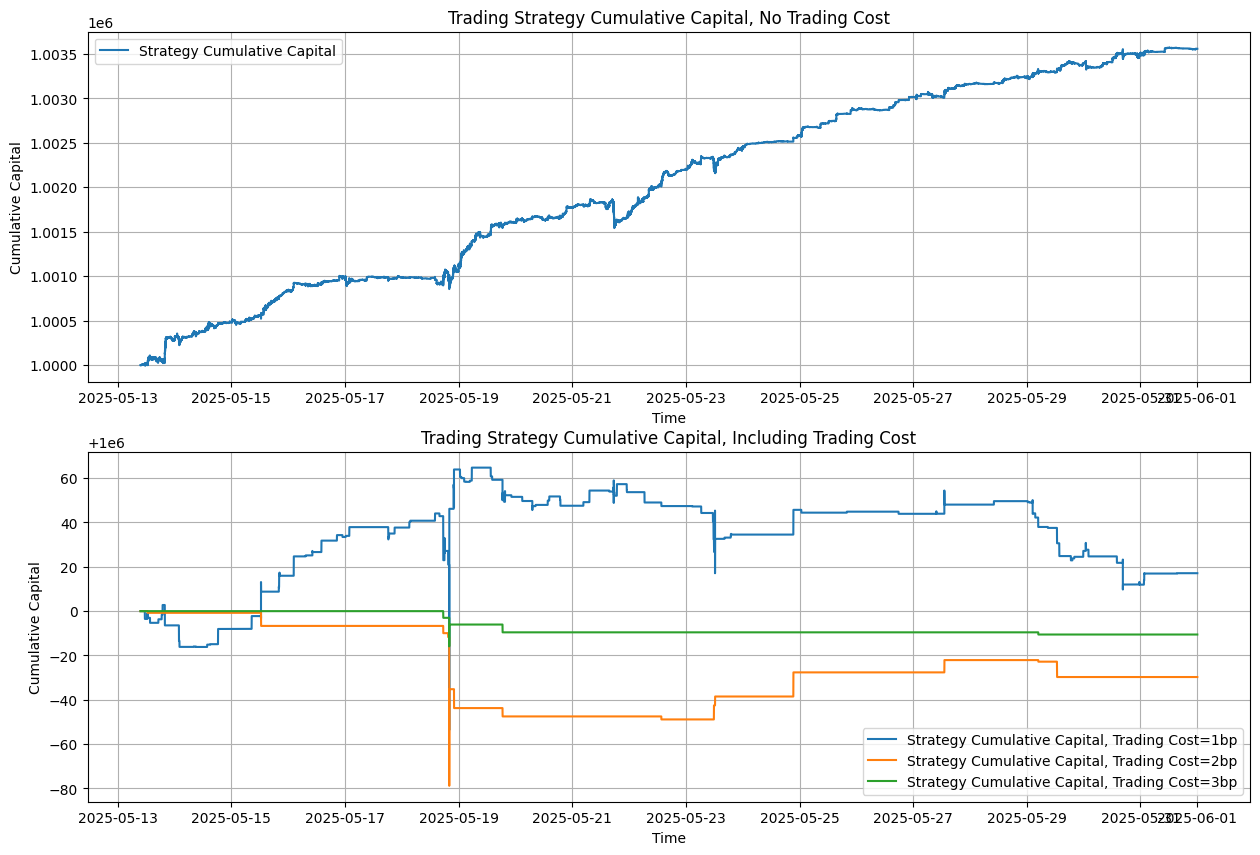


Performance Metrics:
                       Total Return Max Drawdown Total PnL Annualized Sharpe  \
Transaction Cost (bps)                                                         
0                             0.36%       -0.03%  3,559.11             39.52   
1                             0.00%       -0.01%     17.12              0.95   
2                            -0.00%       -0.01%    -29.74             -3.09   
3                            -0.00%       -0.00%    -10.55             -2.77   

                       Win Rate  
Transaction Cost (bps)           
0                        50.66%  
1                        52.24%  
2                        30.77%  
3                        20.00%  



                                              BITSTAMP
----------------------------------------------------------------------------------------------------


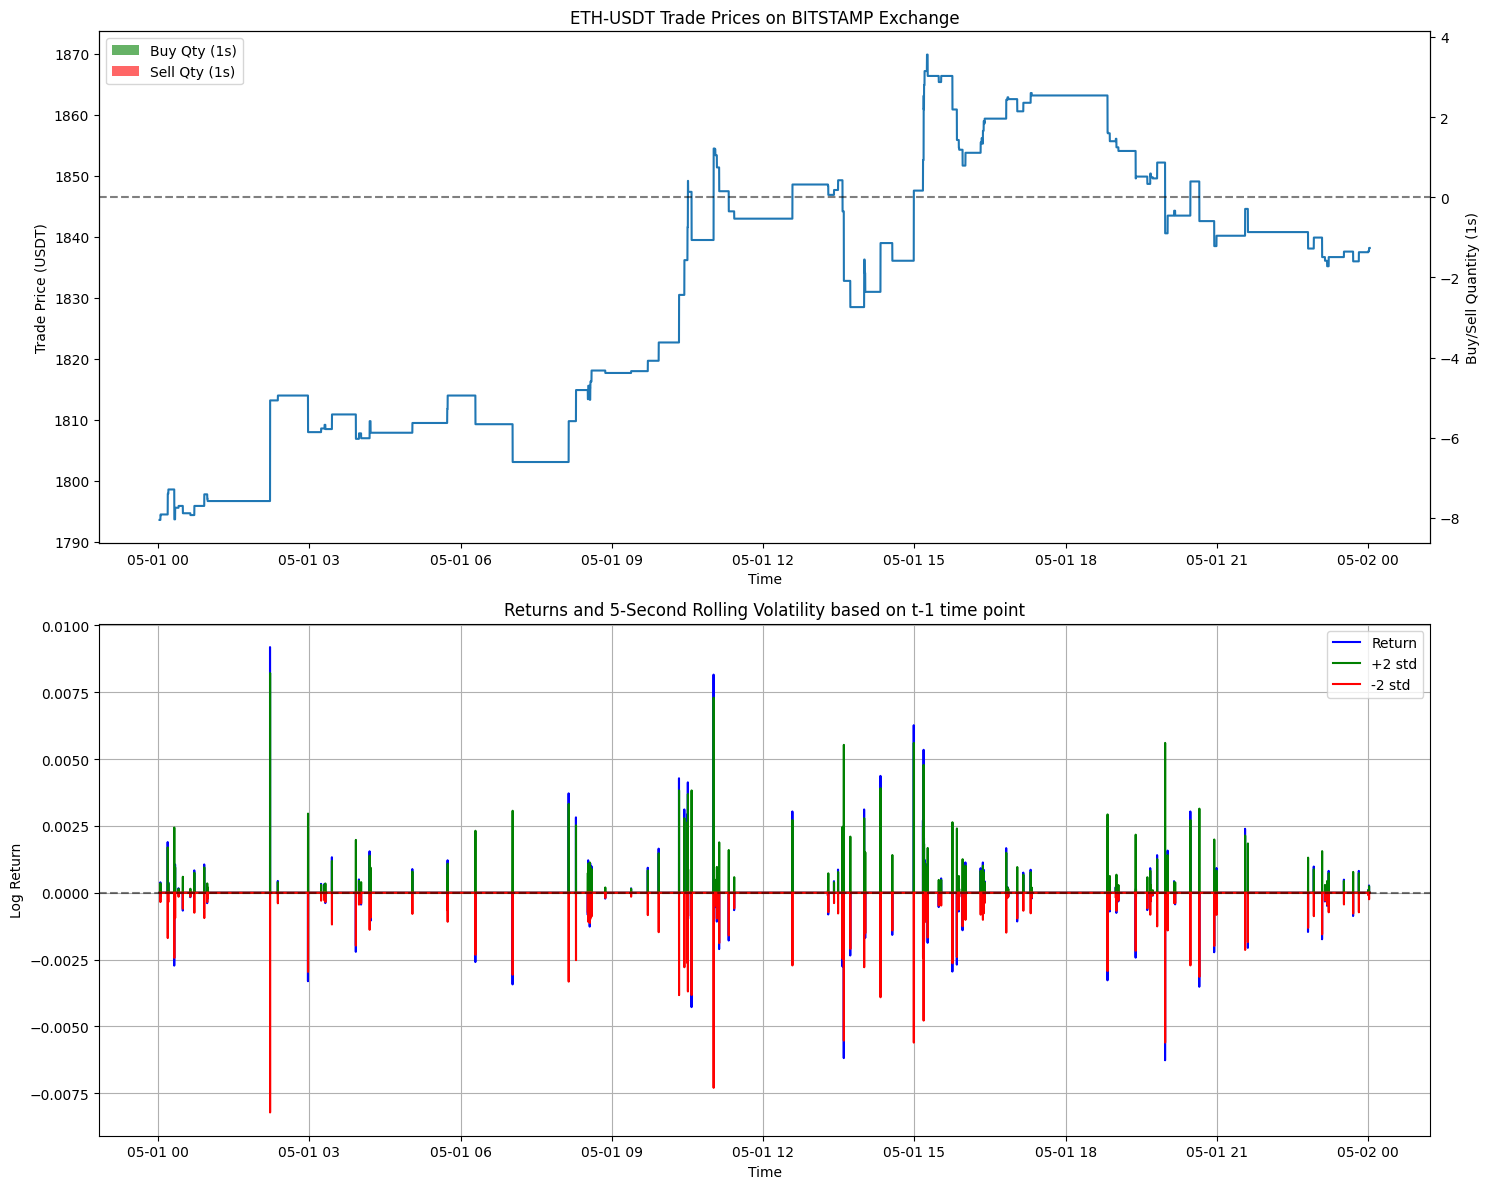

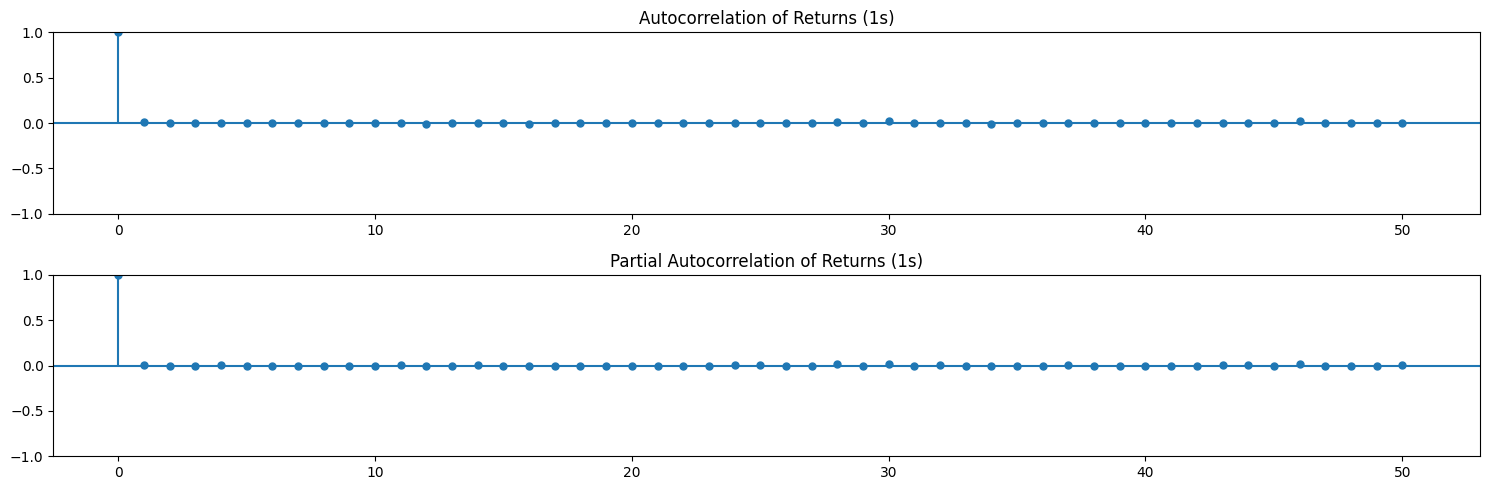

Distribtion is positively skewed
Kurtosis > 3 implies Distribtion has heavy tails
Jarque-Bera test statistic: 61390185253.52291, p-value: 0.0
This indicates that the returns are not normally distributed.

ADF test statistic: -41.7971823045936, p-value: 0.0
This indicates that the returns are stationary.

Starting Variance Inflation Factor (VIF) Analysis
Dropping 'vol_lag_14' (Fast VIF: 30.15)
Dropping 'return_lag_14' (Fast VIF: 29.30)
Dropping 'vol_lag_12' (Fast VIF: 25.70)
Dropping 'return_lag_12' (Fast VIF: 25.11)
Dropping 'vol_lag_10' (Fast VIF: 21.33)
Dropping 'return_lag_10' (Fast VIF: 20.91)
Dropping 'vol_lag_8' (Fast VIF: 17.00)
Dropping 'return_lag_8' (Fast VIF: 16.69)
Dropping 'vol_lag_13' (Fast VIF: 13.84)
Dropping 'return_lag_13' (Fast VIF: 13.39)
Dropping 'vol_lag_6' (Fast VIF: 12.68)
Dropping 'return_lag_6' (Fast VIF: 12.46)
Dropping 'vol_lag_9' (Fast VIF: 9.49)
Dropping 'return_lag_9' (Fast VIF: 9.25)
Dropping 'vol_lag_4' (Fast VIF: 8.40)
Dropping 'return_lag_4' (Fast VIF

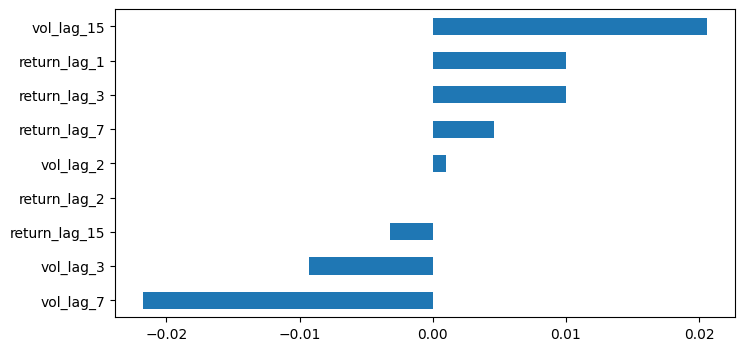

,feature,VIF,beta_coefficient
1,return_lag_2,4.12,0.0000
4,vol_lag_3,3.90,-0.0093
3,return_lag_3,3.86,0.0100
2,vol_lag_2,3.10,0.0010
6,vol_lag_7,2.75,-0.0217
5,return_lag_7,2.69,0.0046
0,return_lag_1,2.02,0.0100
8,vol_lag_15,1.96,0.0206
7,return_lag_15,1.90,-0.0032


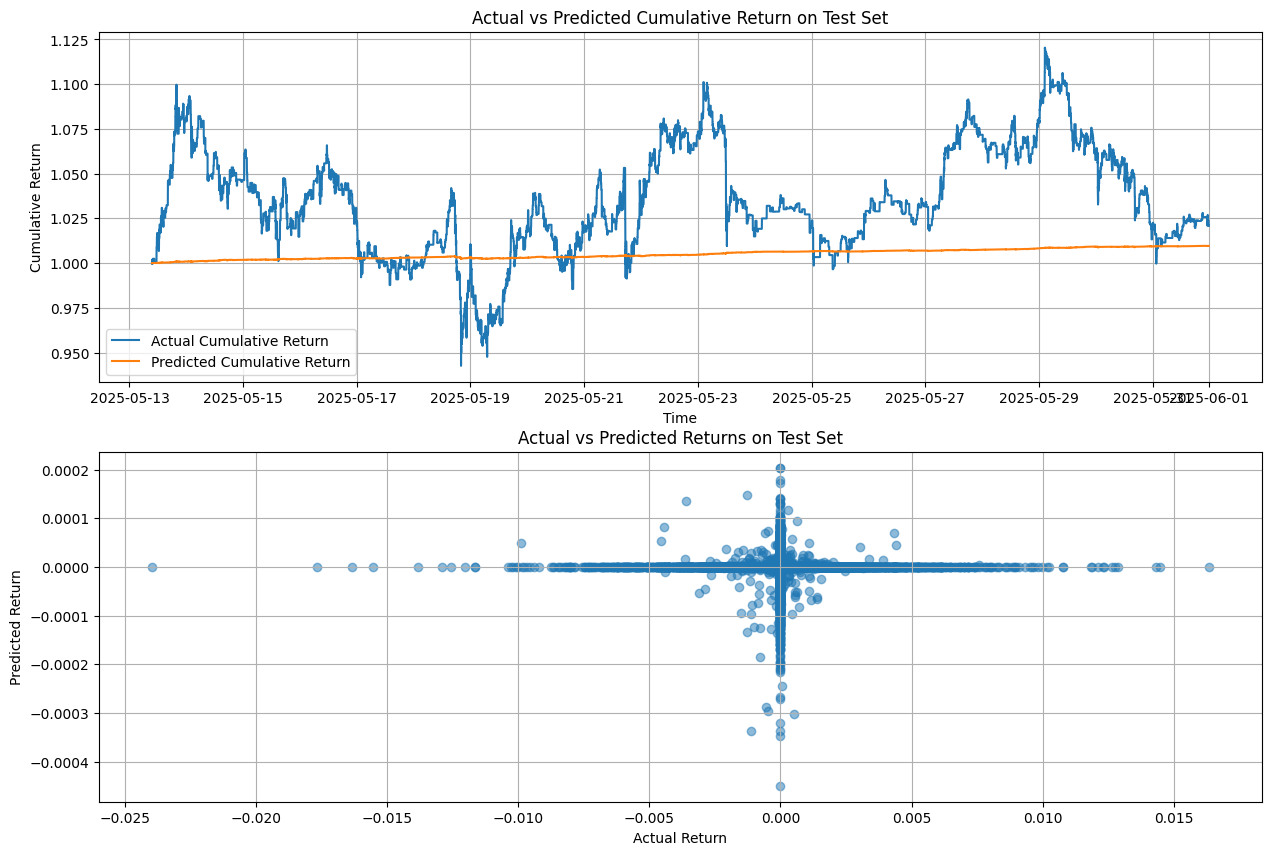

****************************** Win Rate on Test Set: 0.0052 ******************************
******************** Threshold for return_forward_5 trading simulation is 0.00000000 ********************


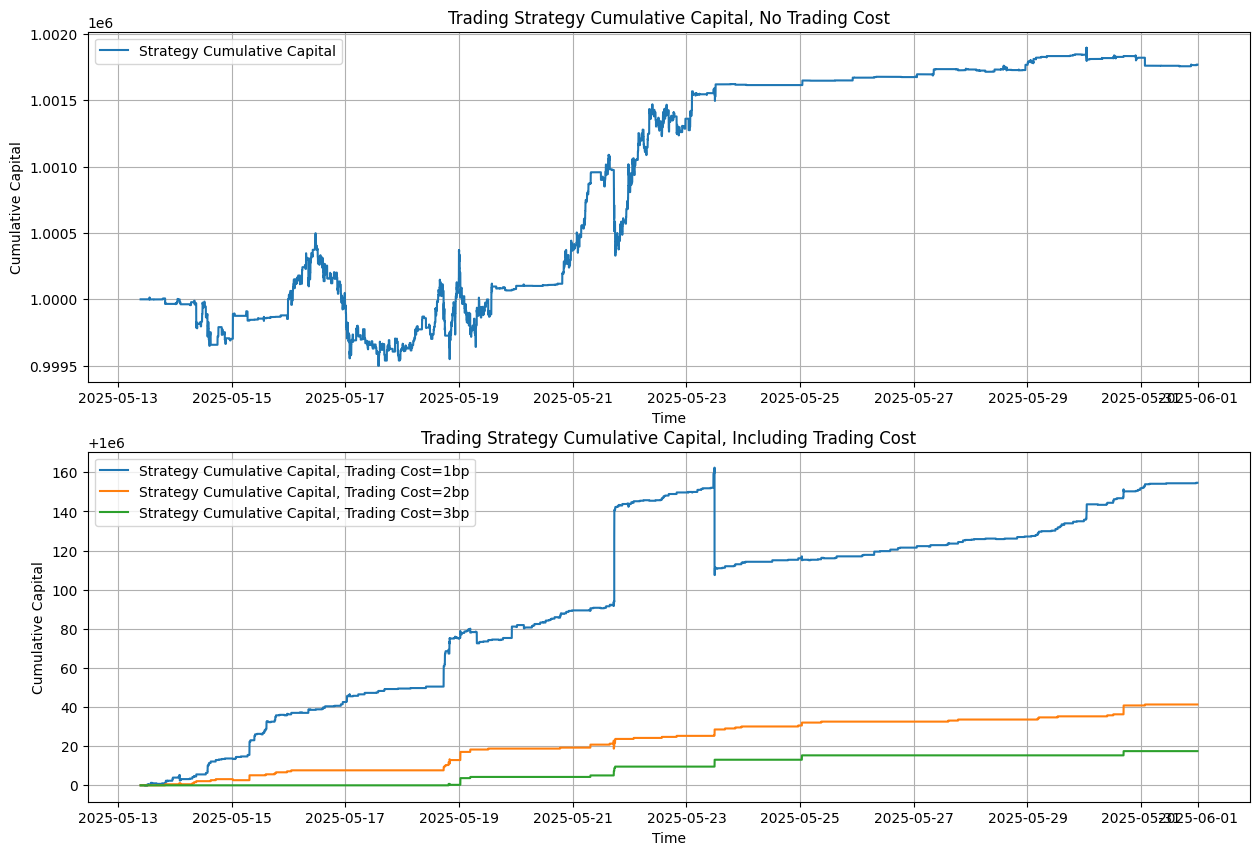


Performance Metrics:
                       Total Return Max Drawdown Total PnL Annualized Sharpe  \
Transaction Cost (bps)                                                         
0                             0.18%       -0.10%  1,768.80             13.25   
1                             0.02%       -0.01%    154.68             18.38   
2                             0.00%       -0.00%     41.33             25.37   
3                             0.00%       -0.00%     17.48             14.55   

                       Win Rate  
Transaction Cost (bps)           
0                         0.70%  
1                        82.37%  
2                        85.71%  
3                        94.44%  



                                              GATE_IO
----------------------------------------------------------------------------------------------------


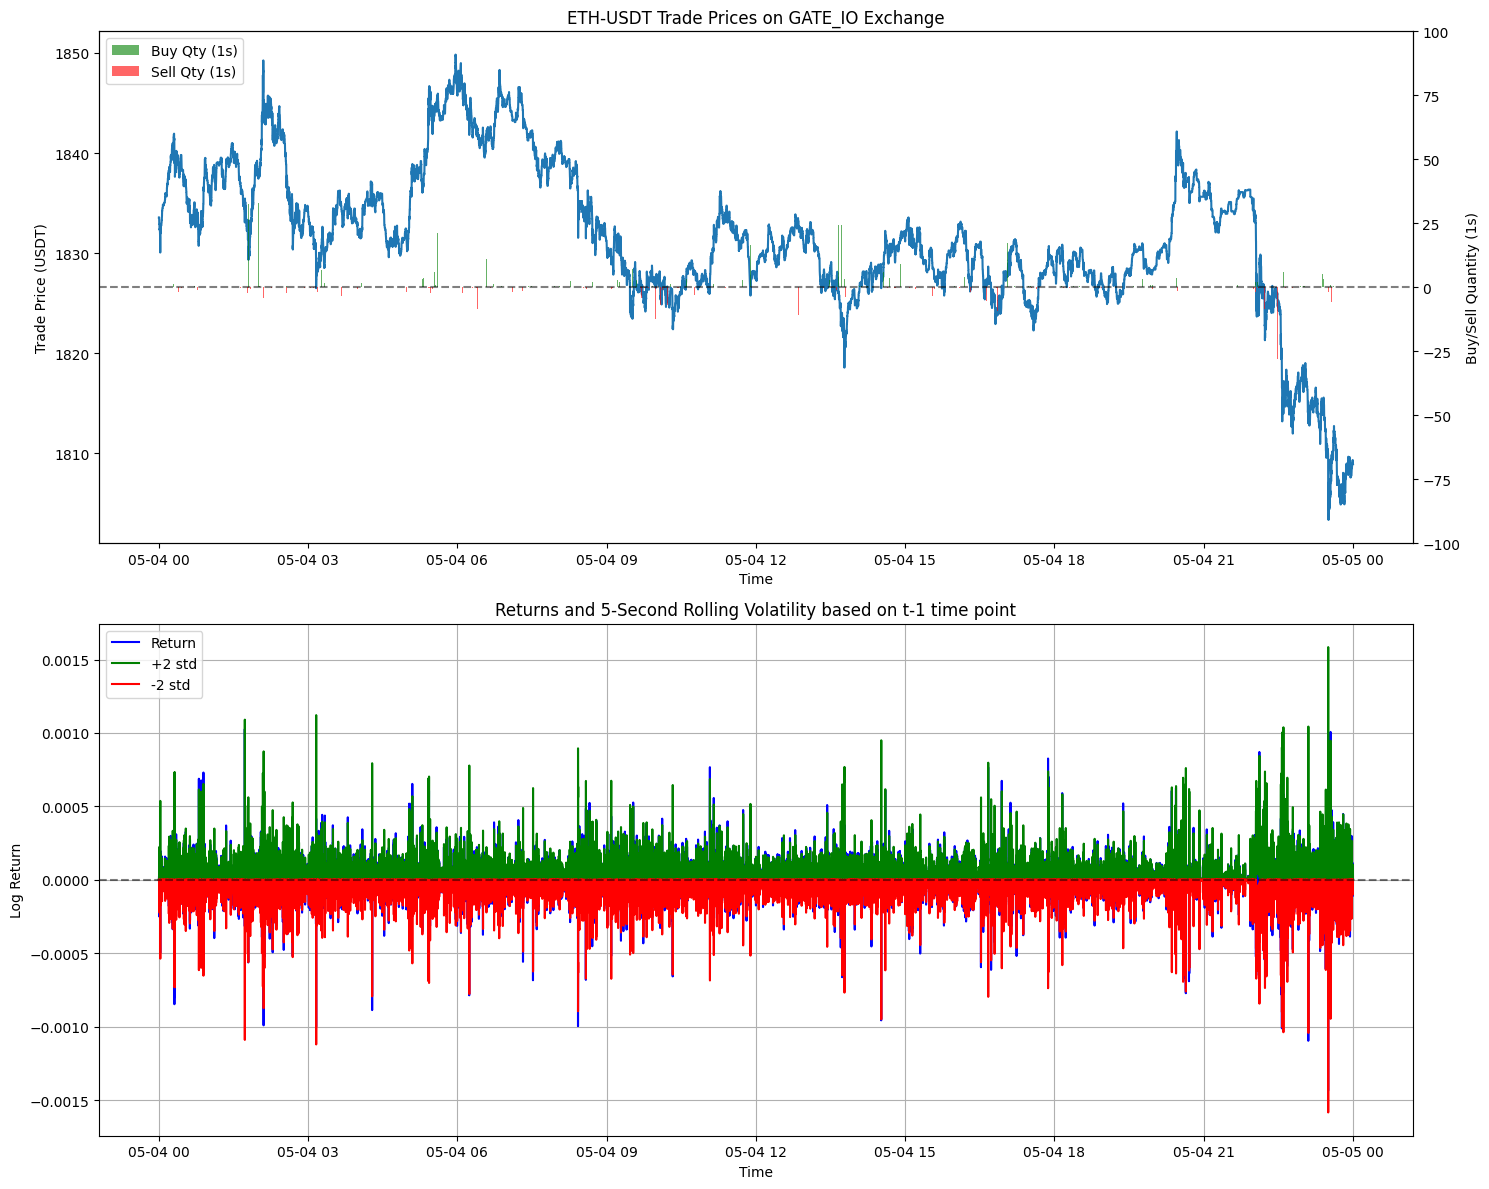

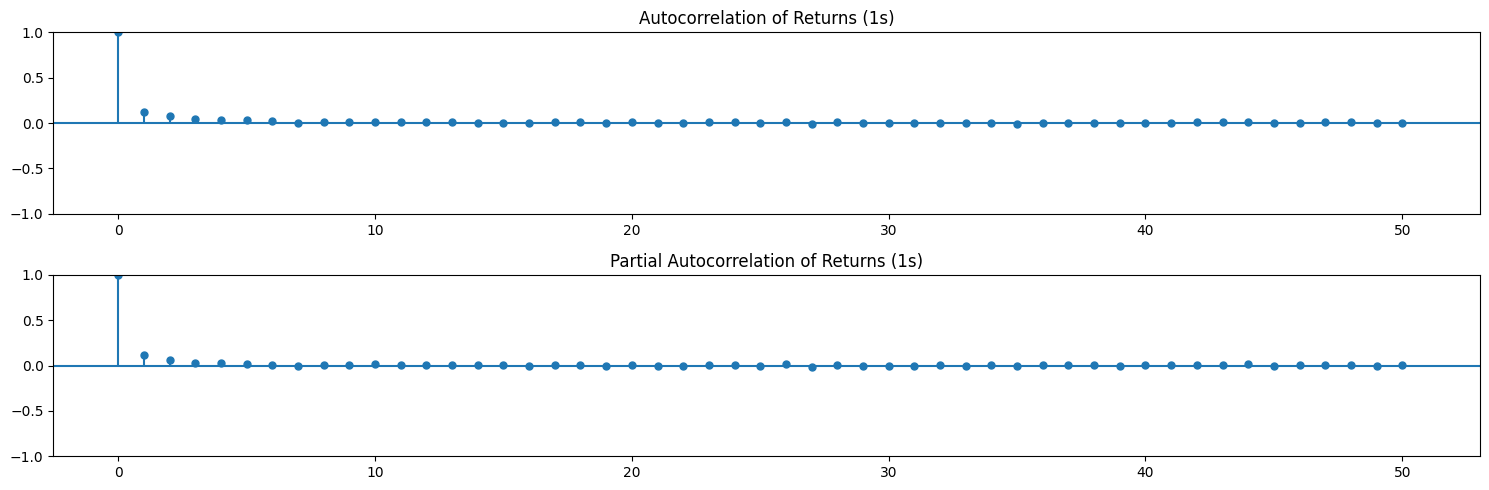

Distribtion is negatively skewed
Kurtosis > 3 implies Distribtion has heavy tails
Jarque-Bera test statistic: 17364205.335928924, p-value: 0.0
This indicates that the returns are not normally distributed.

ADF test statistic: -34.4377911004243, p-value: 0.0
This indicates that the returns are stationary.

Starting Variance Inflation Factor (VIF) Analysis
Dropping 'vol_lag_14' (Fast VIF: 2345.29)
Dropping 'vol_lag_12' (Fast VIF: 1977.15)
Dropping 'vol_lag_10' (Fast VIF: 1607.83)
Dropping 'vol_lag_8' (Fast VIF: 1245.42)
Dropping 'return_lag_13' (Fast VIF: 970.12)
Dropping 'vol_lag_6' (Fast VIF: 892.16)
Dropping 'return_lag_9' (Fast VIF: 643.11)
Dropping 'vol_lag_4' (Fast VIF: 548.17)
Dropping 'return_lag_11' (Fast VIF: 389.41)
Dropping 'return_lag_5' (Fast VIF: 326.76)
Dropping 'return_lag_3' (Fast VIF: 222.95)
Dropping 'return_lag_7' (Fast VIF: 158.91)
Dropping 'return_lag_15' (Fast VIF: 109.21)
Dropping 'vol_lag_2' (Fast VIF: 63.55)
Dropping 'return_lag_14' (Fast VIF: 21.36)
Dropping '

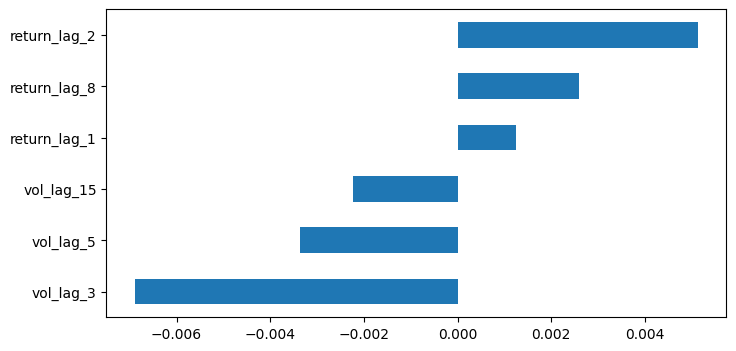

,feature,VIF,beta_coefficient
2,vol_lag_3,4.39,-0.0069
3,vol_lag_5,4.08,-0.0034
1,return_lag_2,3.87,0.0051
4,return_lag_8,3.53,0.0026
5,vol_lag_15,2.09,-0.0022
0,return_lag_1,2.00,0.0013


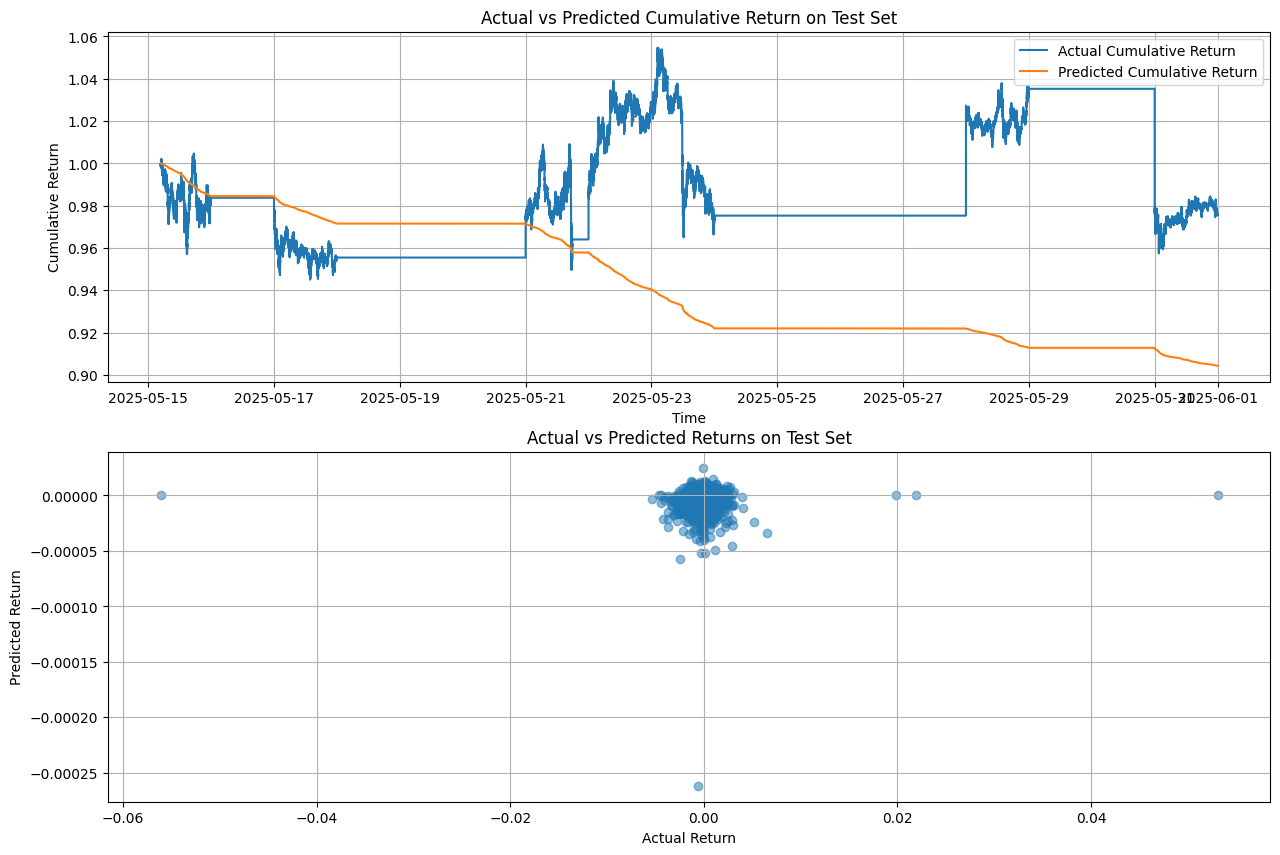

****************************** Win Rate on Test Set: 0.7903 ******************************
******************** Threshold for return_forward_5 trading simulation is 0.00000183 ********************


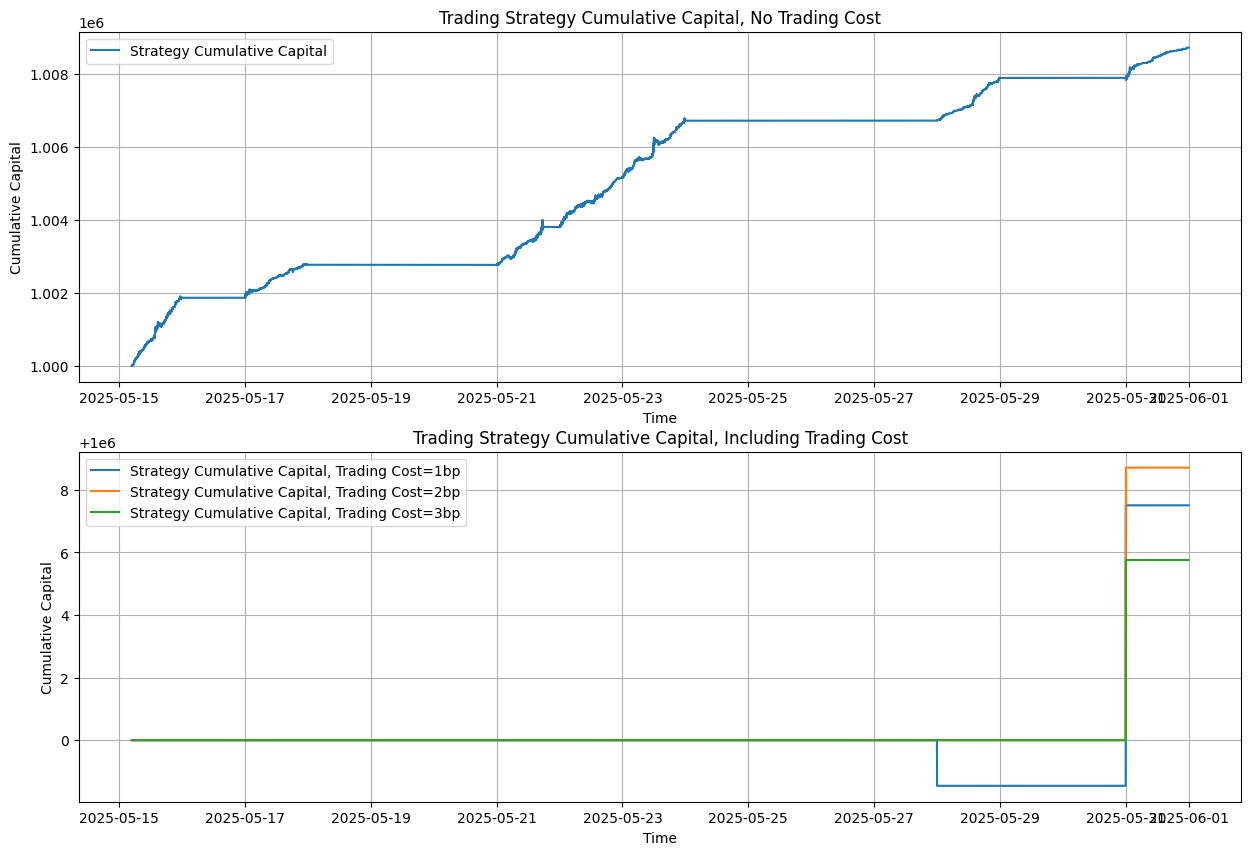


Performance Metrics:
                       Total Return Max Drawdown Total PnL Annualized Sharpe  \
Transaction Cost (bps)                                                         
0                             0.87%       -0.03%  8,729.73            107.59   
1                             0.00%       -0.00%      7.51              9.30   
2                             0.00%        0.00%      8.71             10.29   
3                             0.00%        0.00%      5.76              7.99   

                       Win Rate  
Transaction Cost (bps)           
0                        51.41%  
1                        69.23%  
2                       100.00%  
3                       100.00%  



                                              COINBASE
----------------------------------------------------------------------------------------------------


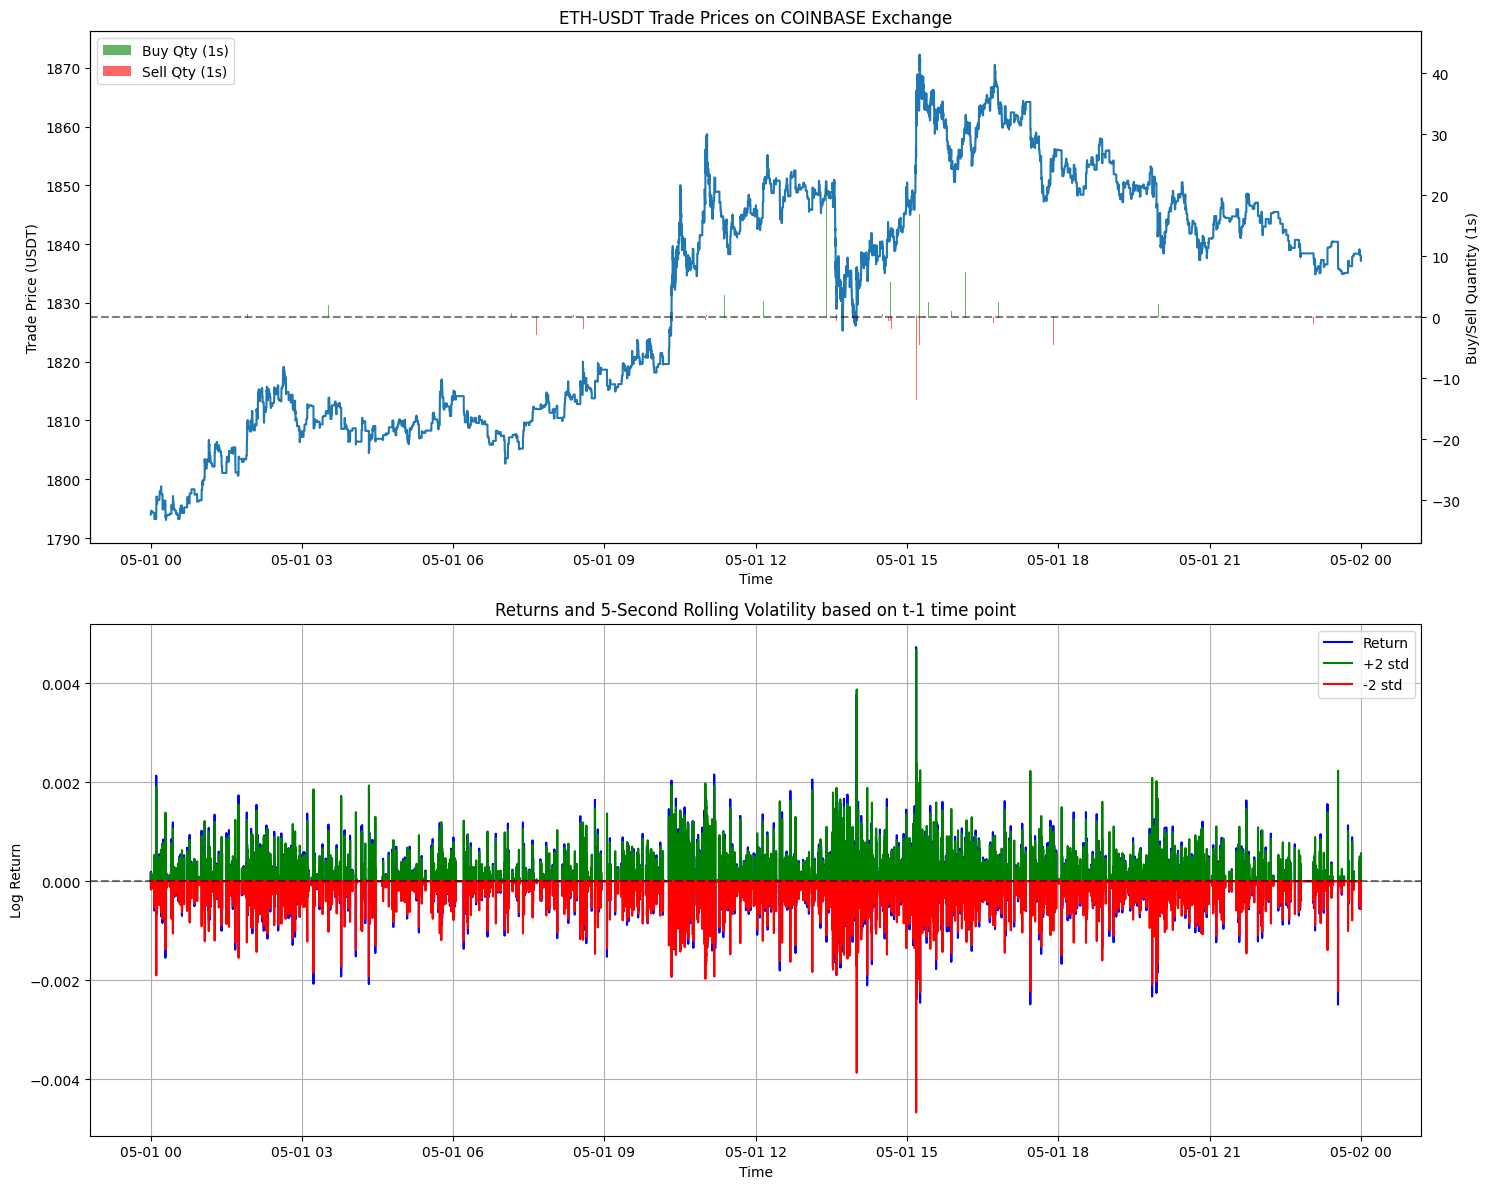

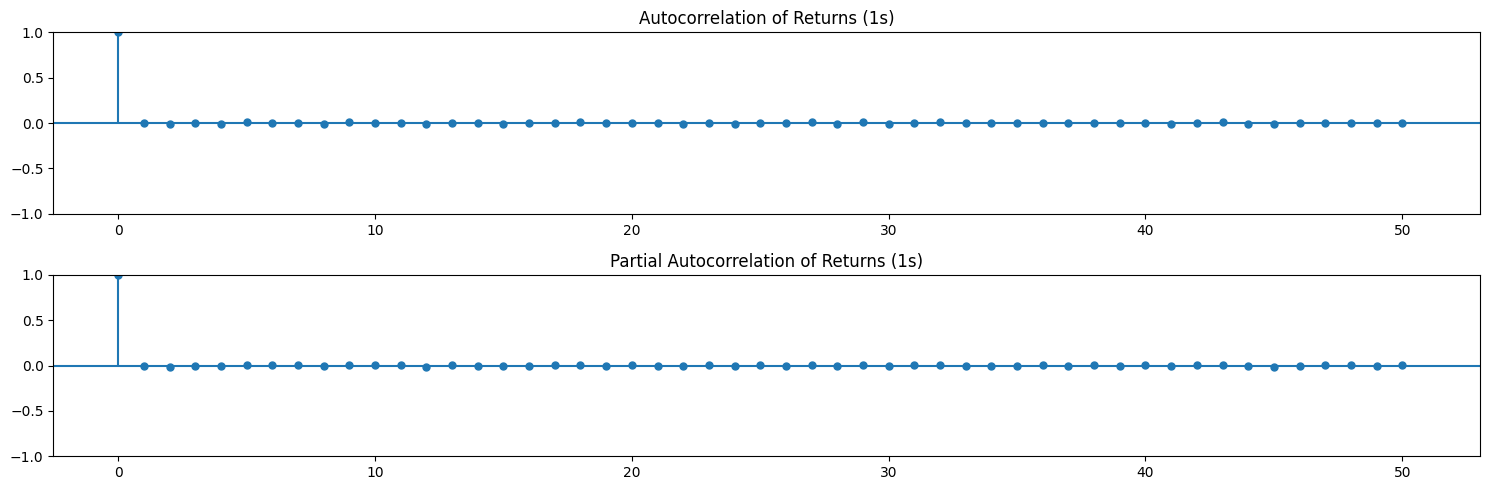

Distribtion is positively skewed
Kurtosis > 3 implies Distribtion has heavy tails
Jarque-Bera test statistic: 154792068.69477096, p-value: 0.0
This indicates that the returns are not normally distributed.

ADF test statistic: -36.89747353827498, p-value: 0.0
This indicates that the returns are stationary.

Starting Variance Inflation Factor (VIF) Analysis
Dropping 'vol_lag_14' (Fast VIF: 46.54)
Dropping 'vol_lag_12' (Fast VIF: 38.62)
Dropping 'vol_lag_10' (Fast VIF: 31.04)
Dropping 'return_lag_14' (Fast VIF: 29.04)
Dropping 'return_lag_12' (Fast VIF: 24.85)
Dropping 'vol_lag_8' (Fast VIF: 23.83)
Dropping 'vol_lag_13' (Fast VIF: 21.15)
Dropping 'return_lag_10' (Fast VIF: 20.66)
Dropping 'vol_lag_6' (Fast VIF: 17.03)
Dropping 'return_lag_8' (Fast VIF: 16.44)
Dropping 'vol_lag_9' (Fast VIF: 13.61)
Dropping 'return_lag_13' (Fast VIF: 13.58)
Dropping 'return_lag_6' (Fast VIF: 12.20)
Dropping 'vol_lag_4' (Fast VIF: 10.57)
Dropping 'return_lag_9' (Fast VIF: 9.35)
Dropping 'vol_lag_11' (Fast V

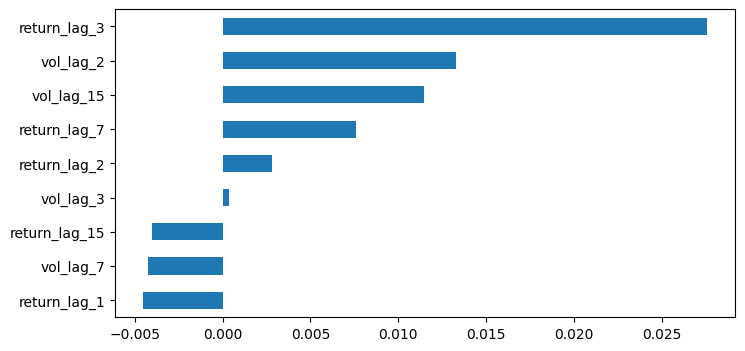

,feature,VIF,beta_coefficient
4,vol_lag_3,4.92,0.0004
6,vol_lag_7,4.36,-0.0043
1,return_lag_2,3.98,0.0028
3,return_lag_3,3.78,0.0276
2,vol_lag_2,3.58,0.0133
8,vol_lag_15,3.05,0.0115
5,return_lag_7,2.71,0.0076
0,return_lag_1,2.00,-0.0045
7,return_lag_15,1.89,-0.0040


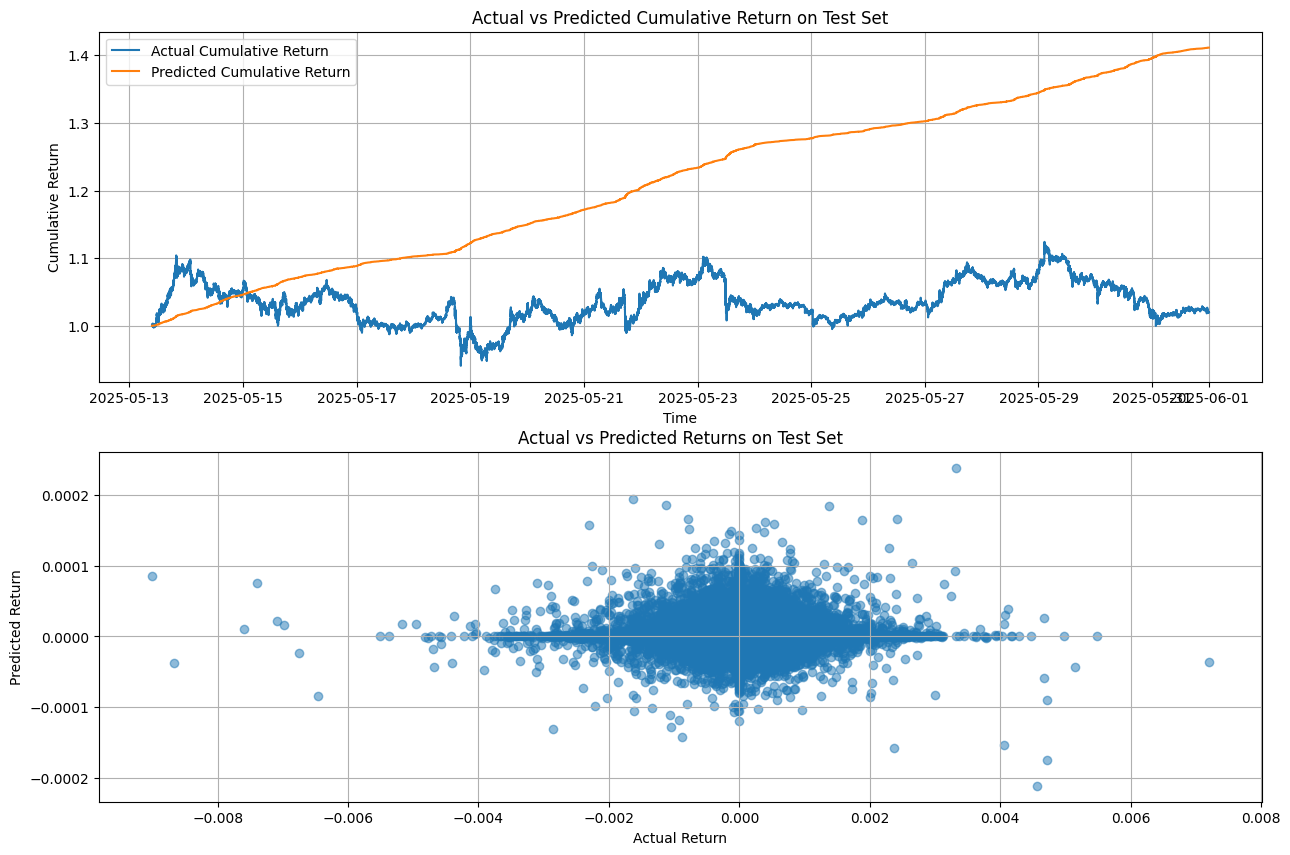

****************************** Win Rate on Test Set: 0.1398 ******************************
******************** Threshold for return_forward_5 trading simulation is 0.00001487 ********************


C:\Users\daddy\AppData\Local\Temp\ipykernel_27244\1077489098.py:26: RuntimeWarning: invalid value encountered in scalar divide
  win_rate = (data_pd[f'strategy_pnl_{tc}bp'] > 0).sum() / data_pd[f'position_{tc}bp'].abs().sum()


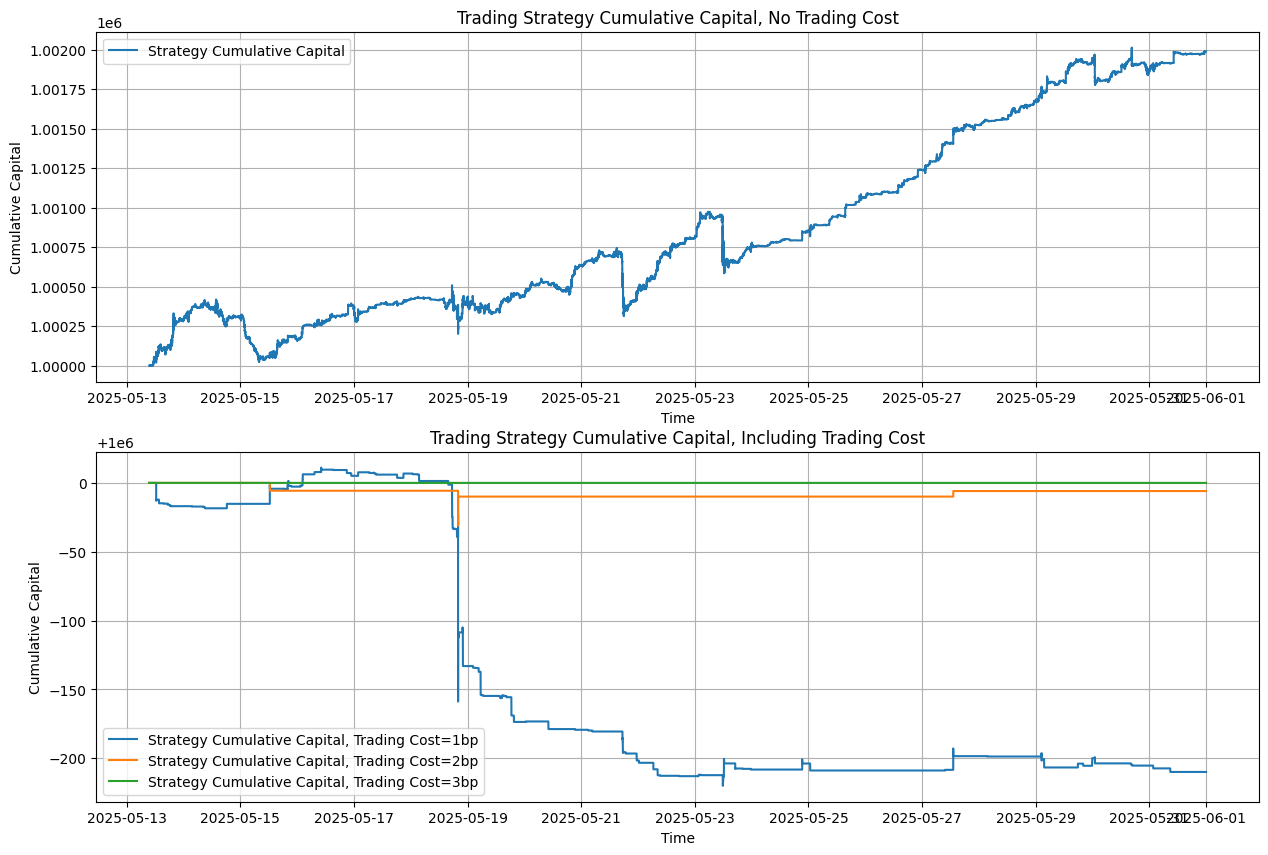


Performance Metrics:
                       Total Return Max Drawdown Total PnL Annualized Sharpe  \
Transaction Cost (bps)                                                         
0                             0.20%       -0.04%  1,988.73             24.73   
1                            -0.02%       -0.02%   -209.87            -14.96   
2                            -0.00%       -0.00%     -5.92             -1.08   
3                             0.00%        0.00%      0.00              0.00   

                       Win Rate  
Transaction Cost (bps)           
0                        25.69%  
1                        28.98%  
2                        50.00%  
3                          nan%  


In [11]:
# Exchanges list
exchanges = ['OKX', 'BITSTAMP', 'GATE_IO', 'COINBASE']
for exchange in exchanges:
    eth_trades = pl.read_parquet(r'data/Crypto/HighFreq/ETH-USDT_fewer_trades.parquet')

    print('\n\n')
    print(' '*45, exchange)
    print("-"*100)

    eth_trades_exch = filter_and_format_data(eth_trades, exchange)
    del eth_trades

    cutoff_time = '1D'
    tests(display_price_volume_and_return_bounds(eth_trades_exch, cutoff_time, exchange))

    reg_data, y_labels, feature_columns = generate_data_for_regression(eth_trades_exch, t=15, Ts=[5])
    del eth_trades_exch


    # divide reg_data into 40% train, 60% test based on timestamp
    n = reg_data.shape[0]
    train_end = int(n * 0.4)

    reg_train = reg_data[:train_end]
    reg_test = reg_data[train_end:]

    for y_label in y_labels:
        model, truncated_feature_columns = perform_training_regression_analysis(reg_train, y_label, feature_columns.copy())
        perform_test_analysis(model, reg_test, y_label, truncated_feature_columns)

        train_return_preds = model.predict(reg_train.select(truncated_feature_columns).to_pandas())
        # Only execute trades on the top 5% of the absolute returns
        threshold = train_return_preds.abs().quantile(0.95)

        simulate_trading_strategy_and_performance_analysis(model, reg_test, y_label, truncated_feature_columns, threshold)

## Observations:

- The statistical power of the regression performed on any of the exchanges is extremely poor which just shows that we are not able to predict the future returns based on our predictors
- Betas assigned to the returns and volatility are inconsistent/unstable as can be seen by analyzing the parameters across different exchanges
- Analysis of beta using different time periods for training and test data show different results, further supporting the view that betas are unstable
- The predicted returns from the regressions are very low which makes the threshold (set as 95th percentile of absolute distribution of returns) extremely low. With a 5% return threshold, there will be no trading
- Hence, we can conclude that model has too much bias and does not predict the returns sufficiently to be useful
- We choose the threshold based on the training set returns to account for the bias in the model
- Using even longer time horizons will be meaningless as our model is very naive and does not capture the variance in the current dataset
- Without trading costs, profits are unbounded
- With trading costs, there is hardly any advantage
- Our regressions have some predictive power (shown by win rate on test data) with respect to the direction of the return but performs very poorly in predicting the magnitude of returns
- There is high multicollinearity in features built based on lagged returns and volatility which we are handling by using VIF Analysis
- Buy and Sell Volume are not useful in predicting future returns as seen consistently by almost zero betas across regressions and exchanges
- BITSTAMP and GATE_IO Exchange have large jumps in ETH data and hence, analysis on those returns is not useful